In [123]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

from chars import greek, phys # a list of useful unicode chars

In [127]:
cwd = Path(os.getcwd())
results_dir = cwd / "WS2_Grating_Eamonn" / "Results"
results_dir.mkdir(exist_ok=True)

project_folder = results_dir / 'ALPHA WS₂, SiO₂, Si 1'
json_path = project_folder / 'summary_alpha.json'

with open(json_path, 'r') as file:
    data = json.load(file)
    
data_df = pd.DataFrame(data)
print(data_df.head())
data_df.info()



                                                   0.4000  \
0.0100  {'0.7000': {'0.0000': [0.4691390317607265, 0.5...   
0.0550  {'0.7000': {'0.0000': [0.6706641446923345, 0.7...   
0.1000  {'0.7000': {'0.0000': [1.0, 0.983103635218265,...   

                                                   0.5000  \
0.0100  {'0.7000': {'0.0000': [1.0, 0.9717044207379012...   
0.0550  {'0.7000': {'0.0000': [0.9539452915394379, 0.9...   
0.1000  {'0.7000': {'0.0000': [1.0, 0.9988232567088717...   

                                                   0.6000  \
0.0100  {'0.7000': {'0.0000': [1.0, 0.9796100328264912...   
0.0550  {'0.7000': {'0.0000': [0.8479206031795481, 0.8...   
0.1000  {'0.7000': {'0.0000': [0.9697311526941559, 0.9...   

                                                   0.7000  \
0.0100  {'0.7000': {'0.0000': [1.0, 0.9847466588999675...   
0.0550  {'0.7000': {'0.0000': [0.8436011160481869, 0.8...   
0.1000  {'0.7000': {'0.0000': [0.9103408610034786, 0.9...   

                    

In [133]:
# period, thickness, filling    units micron where appliacable
choose: List[float] = [0.7, 0.055, 0.7]

choose_str = [f"{s:.4f}" for s in choose]
print(choose_str)

alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
print(len(alpha_layer))

x_axis_str = list(alpha_layer.keys())

x_axis = [float(val) for val in x_axis_str]
print(x_axis)
y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T
y_data

df_reflectivity = pd.DataFrame(y_data)
df_reflectivity.columns = x_axis
df_reflectivity.index = np.linspace(2.2, 1.2, len(df_reflectivity.index))
df_reflectivity.head()


['0.7000', '0.0550', '0.7000']
31
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]


,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30
2.200000,0.843601,0.843606,0.843281,0.843173,0.842940,0.842697,0.842497,0.842361,0.842822,0.843500,...,0.664553,0.653252,0.645720,0.639888,0.634344,0.626311,0.611448,0.602129,0.590419,0.587006
2.194975,0.883012,0.883023,0.882805,0.882773,0.882680,0.882625,0.882662,0.882817,0.883493,0.884398,...,0.708191,0.697178,0.690227,0.685260,0.680853,0.674294,0.661454,0.653131,0.642319,0.638523
2.189950,0.917202,0.917219,0.917095,0.917129,0.917154,0.917252,0.917470,0.917838,0.918639,0.919654,...,0.750059,0.740027,0.734229,0.730630,0.727844,0.723251,0.712943,0.706079,0.696588,0.692720
2.184925,0.945632,0.945653,0.945603,0.945683,0.945791,0.945989,0.946319,0.946805,0.947632,0.948640,...,0.789446,0.780857,0.776545,0.774568,0.773639,0.771271,0.763782,0.758700,0.750843,0.747185
2.179899,0.967845,0.967867,0.967866,0.967966,0.968113,0.968351,0.968712,0.969216,0.969966,0.970853,...,0.825577,0.818654,0.815910,0.815548,0.816442,0.816287,0.811642,0.808486,0.802442,0.799233


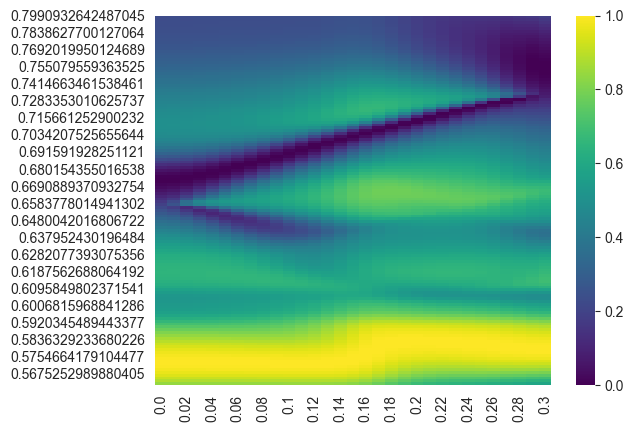

In [134]:
import seaborn as sns

df_reflec_wave = df_reflectivity.copy()
df_reflec_wave.index = 1.24/df_reflectivity.index
df_reflec_wave = df_reflec_wave.sort_index(ascending=False)
df_reflec_wave.head()

df_cropped = df_reflec_wave.query('index <= 0.8')
df_cropped = df_cropped.loc[:, :]

sns.heatmap(df_cropped, cmap='viridis')

plt.show()


In [132]:
alpha_layer = data[choose_str[0]].keys()
alpha_layer

dict_keys(['0.0100', '0.0550', '0.1000'])